In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1    sex        1338 non-null   str    
 2    bmi        1338 non-null   float64
 3    children   1338 non-null   int64  
 4    smoker     1338 non-null   str    
 5    region     1338 non-null   str    
 6    charges    1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe(include='number')

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
data.describe(include='string')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [8]:
print("number of null values in each column : ")
data.isnull().sum()

number of null values in each column : 


age           0
 sex          0
 bmi          0
 children     0
 smoker       0
 region       0
 charges      0
dtype: int64

In [9]:
print("number of duplicate rows in the dataset : ")
data.duplicated().sum()

number of duplicate rows in the dataset : 


np.int64(1)

In [10]:
data.drop_duplicates(inplace=True)

In [11]:
data.columns = data.columns.str.strip()

In [12]:
print("Columns list:", data.columns.tolist())

Columns list: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


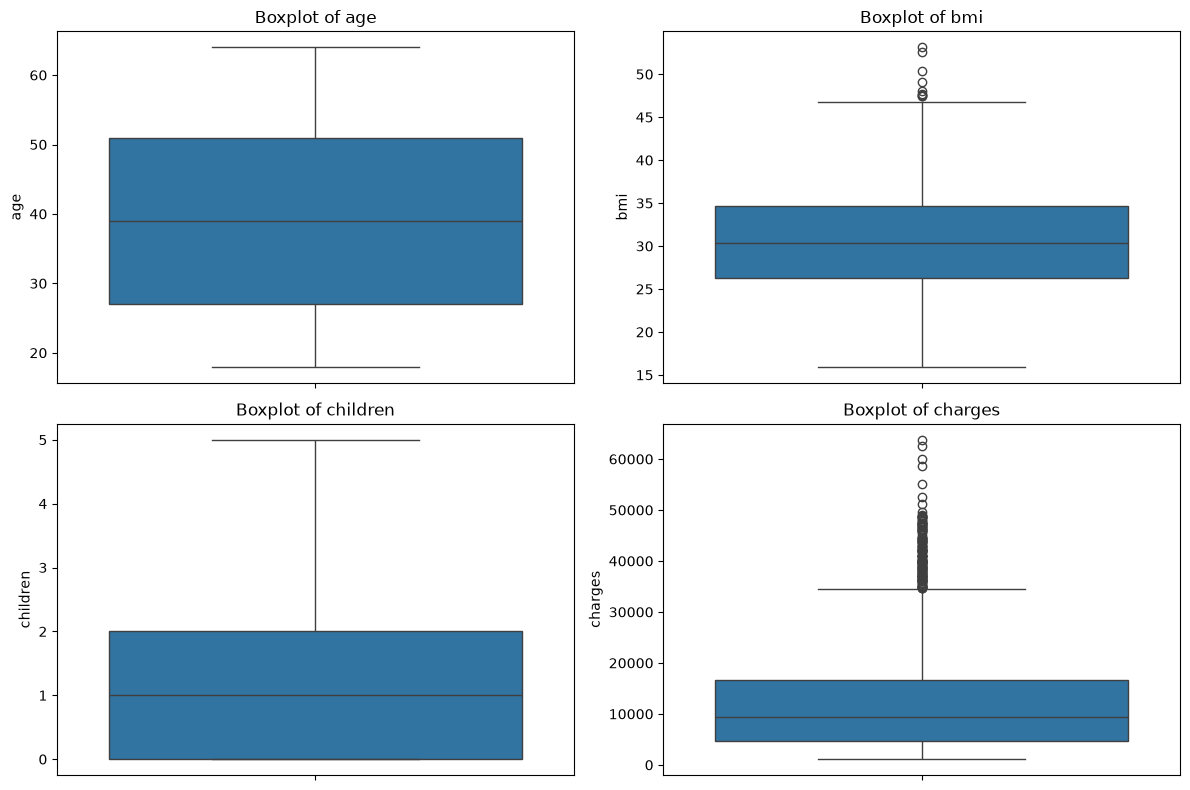

In [13]:
num_cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Charges by Smoking Status')

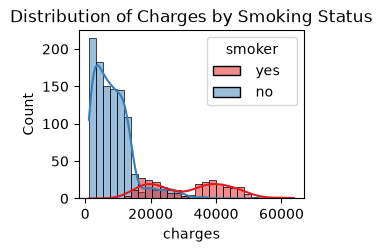

In [14]:
plt.subplot(2, 2, 1)
sns.histplot(data=data, x='charges', hue='smoker', kde=True, palette='Set1')
plt.title('Distribution of Charges by Smoking Status')

In [15]:
cat_cols = ['sex', 'smoker', 'region', 'children']

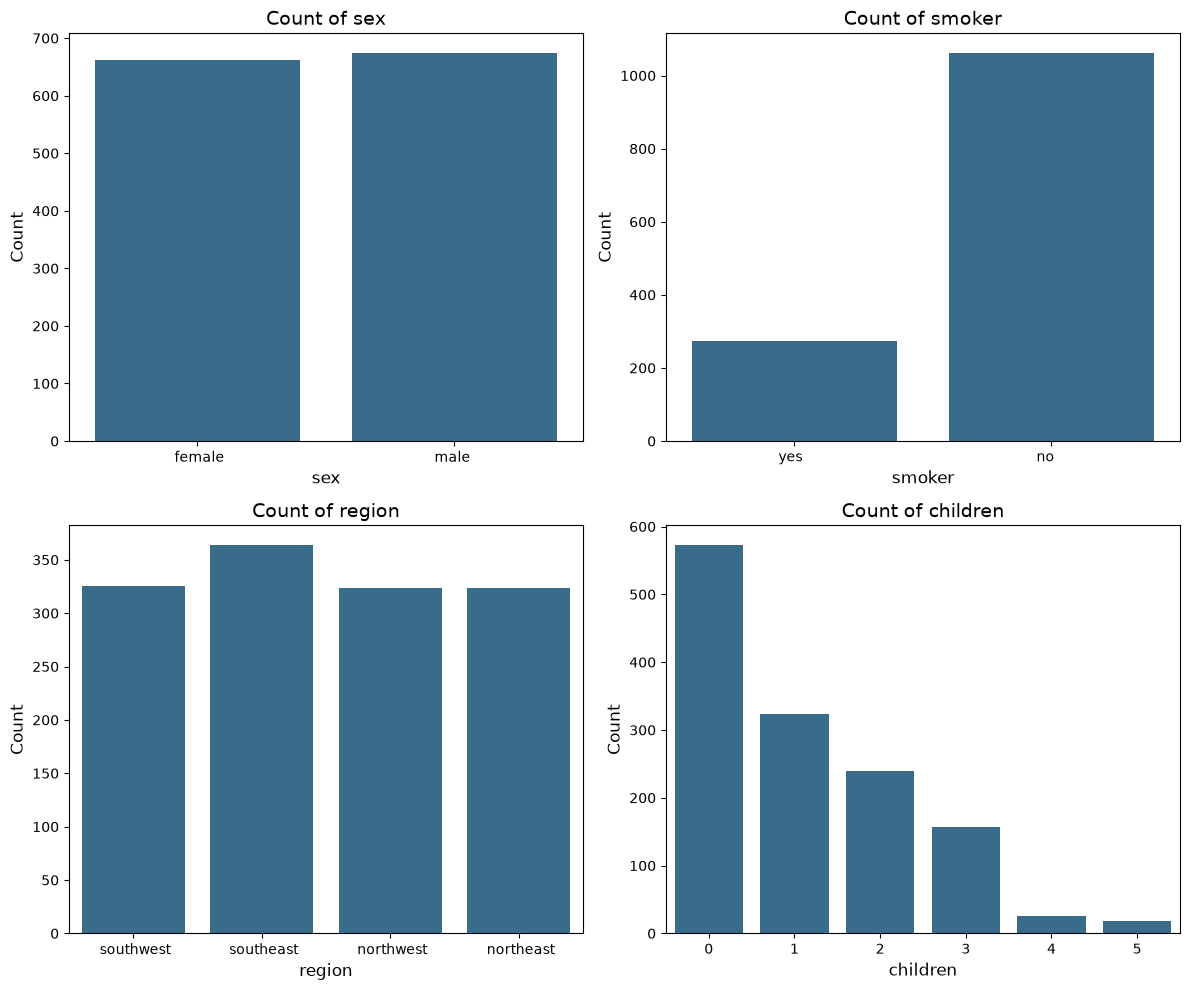

In [16]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=data, x=col, color='#2c6f98')
    
    plt.title(f'Count of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
corr=data.corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


Data Preprocessing

In [18]:
from category_encoders import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [19]:
str_cols = ['sex', 'smoker', 'region']

In [20]:
encoder = OneHotEncoder(cols=str_cols, use_cat_names=True)
data = encoder.fit_transform(data)

data.head()

,age,sex_ female,sex_ male,bmi,children,smoker_ yes,smoker_ no,region_ southwest,region_ southeast,region_ northwest,region_ northeast,charges
0,19,1,0,27.900,0,1,0,1,0,0,0,16884.92400
1,18,0,1,33.770,1,0,1,0,1,0,0,1725.55230
2,28,0,1,33.000,3,0,1,0,1,0,0,4449.46200
3,33,0,1,22.705,0,0,1,0,0,1,0,21984.47061
4,32,0,1,28.880,0,0,1,0,0,1,0,3866.85520


In [21]:
x=data.drop('charges', axis=1)
y=data['charges']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
numeric_features = ['age', 'bmi']
scaler = StandardScaler()
x_train[numeric_features] = scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features] = scaler.transform(x_test[numeric_features])

In [24]:
print("X_train info:")
print(x_train.info())

X_train info:
<class 'pandas.DataFrame'>
Index: 1069 entries, 1114 to 1127
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1069 non-null   float64
 1   sex_ female        1069 non-null   int64  
 2   sex_ male          1069 non-null   int64  
 3   bmi                1069 non-null   float64
 4   children           1069 non-null   int64  
 5   smoker_ yes        1069 non-null   int64  
 6   smoker_ no         1069 non-null   int64  
 7   region_ southwest  1069 non-null   int64  
 8   region_ southeast  1069 non-null   int64  
 9   region_ northwest  1069 non-null   int64  
 10  region_ northeast  1069 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 100.2 KB
None


In [25]:
print("X_train data types:")
print(x_train.dtypes)

print("\nY_train data type:")
print(y_train.dtype)

print("\nAre all X values numerical?")
print(x_train.select_dtypes(exclude=np.number).columns.tolist())

print("\nIs Y numerical?")
print(pd.api.types.is_numeric_dtype(y_train))

X_train data types:
age                  float64
sex_ female            int64
sex_ male              int64
bmi                  float64
children               int64
smoker_ yes            int64
smoker_ no             int64
region_ southwest      int64
region_ southeast      int64
region_ northwest      int64
region_ northeast      int64
dtype: object

Y_train data type:
float64

Are all X values numerical?
[]

Is Y numerical?
True
